In [1]:
# ============================================
# CELDA 1: Importaciones
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas")

✅ Librerías importadas


In [2]:
# ============================================
# CELDA 2: Carga de datos procesados
# ============================================
X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_labels.csv')['label']

print(f"✅ Datos cargados")
print(f"📊 Shape    : {X.shape}")
print(f"📊 Sensores : {X.shape[1]}")
print(f"📊 Muestras : {X.shape[0]:,}")
print(f"\nDistribución real:")
print(f"  OK   (-1): {(y==-1).sum():,} ({(y==-1).mean()*100:.1f}%)")
print(f"  FAIL ( 1): {(y== 1).sum():,}  ({(y==1).mean()*100:.1f}%)")

✅ Datos cargados
📊 Shape    : (1567, 297)
📊 Sensores : 297
📊 Muestras : 1,567

Distribución real:
  OK   (-1): 1,463 (93.4%)
  FAIL ( 1): 104  (6.6%)


In [10]:
# ============================================
# CELDA 3: Isolation Forest
# ============================================

# contamination = % esperado de anomalías
# Sabemos del EDA que ~6% son fallas
# Le damos esa información al modelo
CONTAMINATION = 0.15

model = IsolationForest(
    n_estimators    = 200,      # número de árboles
    contamination   = CONTAMINATION,
    max_samples     = 'auto',
    random_state    = 42,
    n_jobs          = -1        # usa todos los núcleos
)

print("⏳ Entrenando Isolation Forest...")
model.fit(X)
print("✅ Modelo entrenado")

# Predicciones
# Isolation Forest devuelve: -1 = anomalía, 1 = normal
y_pred = model.predict(X)

# Scores de anomalía — más negativo = más anómalo
anomaly_scores = model.score_samples(X)

print(f"\n📊 Anomalías detectadas: {(y_pred == -1).sum()}")
print(f"📊 Normal detectados  : {(y_pred ==  1).sum()}")
print(f"📊 % anomalías        : {(y_pred == -1).mean()*100:.1f}%")

⏳ Entrenando Isolation Forest...
✅ Modelo entrenado

📊 Anomalías detectadas: 235
📊 Normal detectados  : 1332
📊 % anomalías        : 15.0%


RESULTADOS vs ETIQUETAS REALES
              precision    recall  f1-score   support

 Normal (-1)       0.91      0.15      0.25      1463
Anomalía (1)       0.06      0.80      0.12       104

    accuracy                           0.19      1567
   macro avg       0.49      0.47      0.18      1567
weighted avg       0.85      0.19      0.24      1567



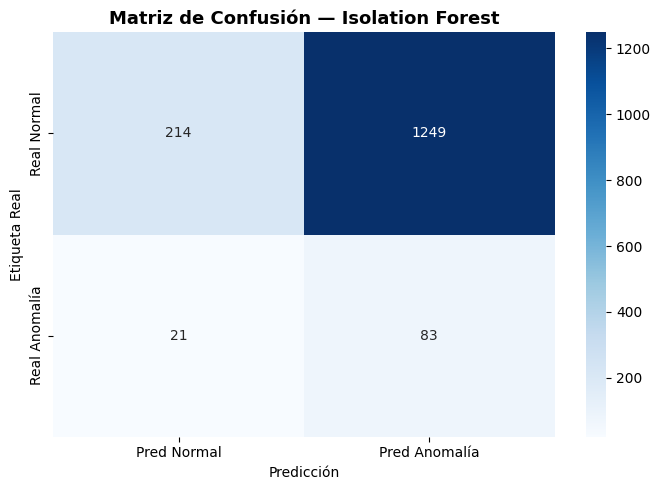

In [12]:
# ============================================
# CELDA 4: Comparación con etiquetas reales
# ============================================
from sklearn.metrics import classification_report, confusion_matrix

# Convertimos etiquetas reales al mismo formato
# SECOM: -1=OK, 1=FAIL
# Isolation Forest: 1=normal, -1=anomalía
# Ya están en el mismo formato ✅

print("=" * 50)
print("RESULTADOS vs ETIQUETAS REALES")
print("=" * 50)
print(classification_report(
    y, y_pred,
    target_names=['Normal (-1)', 'Anomalía (1)'],
    zero_division=0
))

# Matriz de confusión
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Anomalía'],
            yticklabels=['Real Normal', 'Real Anomalía'],
            ax=ax)
ax.set_title('Matriz de Confusión — Isolation Forest',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Predicción')
plt.tight_layout()
plt.savefig('../src/confusion_matrix.png', dpi=150)
plt.show()

📊 Varianza explicada por PCA:
   Componente 1: 8.3%
   Componente 2: 5.1%
   Total       : 13.4%


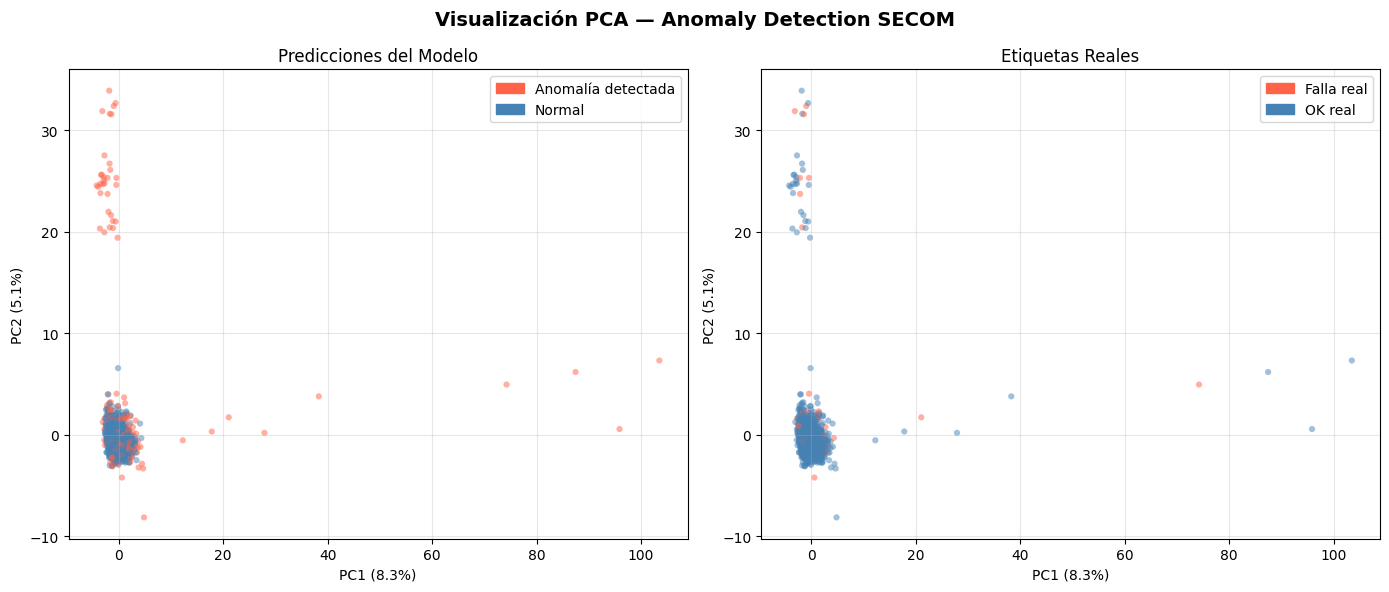

✅ Gráfica PCA guardada


In [13]:
# ============================================
# CELDA 5: Visualización 2D con PCA
# ============================================

# 297 sensores no se pueden graficar directamente
# PCA los comprime a 2 dimensiones para visualizar

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

print(f"📊 Varianza explicada por PCA:")
print(f"   Componente 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"   Componente 2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"   Total       : {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Visualización PCA — Anomaly Detection SECOM',
             fontsize=14, fontweight='bold')

# Gráfica 1: Predicciones del modelo
ax1 = axes[0]
colors_pred = ['tomato' if p == -1 else 'steelblue' for p in y_pred]
ax1.scatter(X_2d[:, 0], X_2d[:, 1],
            c=colors_pred, alpha=0.5, s=20, edgecolors='none')
ax1.set_title('Predicciones del Modelo')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
from matplotlib.patches import Patch
legend = [Patch(color='tomato', label='Anomalía detectada'),
          Patch(color='steelblue', label='Normal')]
ax1.legend(handles=legend)
ax1.grid(True, alpha=0.3)

# Gráfica 2: Etiquetas reales
ax2 = axes[1]
colors_real = ['tomato' if p == 1 else 'steelblue' for p in y]
ax2.scatter(X_2d[:, 0], X_2d[:, 1],
            c=colors_real, alpha=0.5, s=20, edgecolors='none')
ax2.set_title('Etiquetas Reales')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
legend2 = [Patch(color='tomato', label='Falla real'),
           Patch(color='steelblue', label='OK real')]
ax2.legend(handles=legend2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/pca_visualization.png', dpi=150)
plt.show()
print("✅ Gráfica PCA guardada")

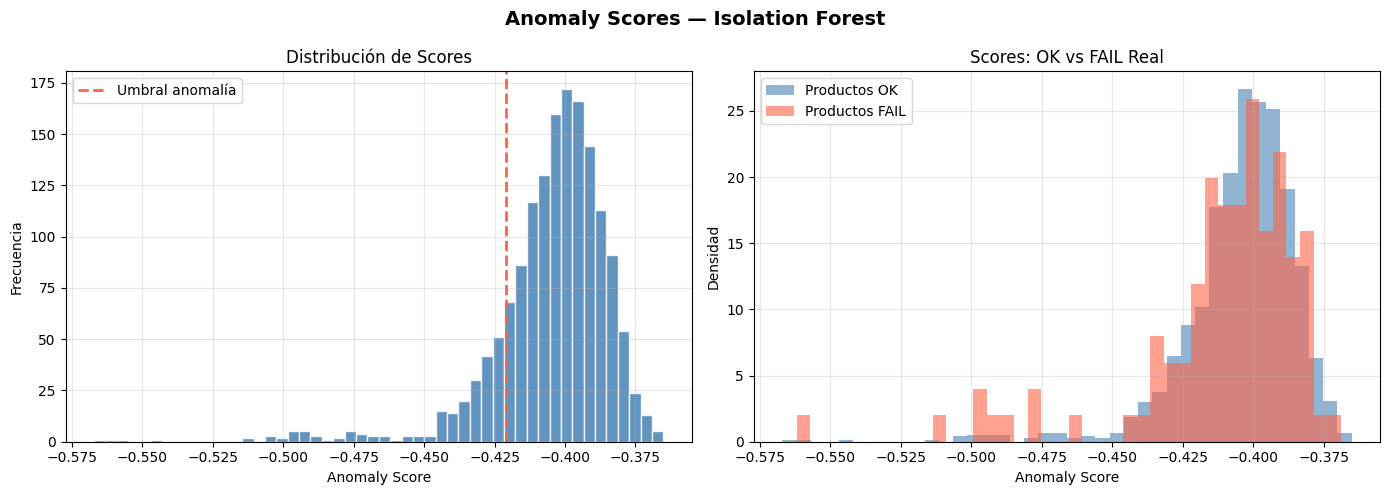

✅ Gráfica guardada


In [14]:
# ============================================
# CELDA 6: Distribución de scores de anomalía
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anomaly Scores — Isolation Forest',
             fontsize=14, fontweight='bold')

# Gráfica 1: Distribución general de scores
ax1 = axes[0]
ax1.hist(anomaly_scores, bins=50,
         color='steelblue', edgecolor='white', alpha=0.85)
threshold = np.percentile(anomaly_scores, CONTAMINATION * 100)
ax1.axvline(x=threshold, color='tomato', linewidth=2,
            linestyle='--', label=f'Umbral anomalía')
ax1.set_xlabel('Anomaly Score')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Scores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Scores por clase real
ax2 = axes[1]
scores_ok   = anomaly_scores[y == -1]
scores_fail = anomaly_scores[y ==  1]
ax2.hist(scores_ok, bins=40, alpha=0.6,
         color='steelblue', label='Productos OK', density=True)
ax2.hist(scores_fail, bins=40, alpha=0.6,
         color='tomato', label='Productos FAIL', density=True)
ax2.set_xlabel('Anomaly Score')
ax2.set_ylabel('Densidad')
ax2.set_title('Scores: OK vs FAIL Real')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/anomaly_scores.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")

In [15]:
# ============================================
# CELDA 7: Guarda el modelo
# ============================================
import os

os.makedirs('../src/model', exist_ok=True)

with open('../src/model/isolation_forest.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../src/model/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

# Guardamos scores para el notebook 04
pd.DataFrame({
    'anomaly_score': anomaly_scores,
    'prediction'   : y_pred,
    'label_real'   : y.values
}).to_csv('../data/predictions.csv', index=False)

print("✅ Archivos guardados:")
print(f"   src/model/isolation_forest.pkl")
print(f"   src/model/pca_model.pkl")
print(f"   data/predictions.csv")

✅ Archivos guardados:
   src/model/isolation_forest.pkl
   src/model/pca_model.pkl
   data/predictions.csv


In [16]:
# ============================================
# CELDA 8: Resumen
# ============================================
from sklearn.metrics import recall_score, precision_score

precision = precision_score(y, y_pred, pos_label=-1, zero_division=0)
recall    = recall_score(y, y_pred, pos_label=-1, zero_division=0)

print("=" * 50)
print("RESUMEN — Anomaly Detection")
print("=" * 50)
print(f"""
Modelo        : Isolation Forest
Sensores      : {X.shape[1]}
Muestras      : {X.shape[0]:,}
Contaminación : {CONTAMINATION*100:.0f}%

Resultados:
  Anomalías detectadas : {(y_pred==-1).sum()}
  Fallas reales        : {(y==1).sum()}
  Precision            : {precision:.3f}
  Recall               : {recall:.3f}

Archivos:
  ✅ src/model/isolation_forest.pkl
  ✅ src/model/pca_model.pkl
  ✅ data/predictions.csv

Siguiente paso → 04_evaluation.ipynb
""")

RESUMEN — Anomaly Detection

Modelo        : Isolation Forest
Sensores      : 297
Muestras      : 1,567
Contaminación : 15%

Resultados:
  Anomalías detectadas : 235
  Fallas reales        : 104
  Precision            : 0.911
  Recall               : 0.146

Archivos:
  ✅ src/model/isolation_forest.pkl
  ✅ src/model/pca_model.pkl
  ✅ data/predictions.csv

Siguiente paso → 04_evaluation.ipynb

